In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
x,y = make_blobs(n_samples=1000, centers=4, cluster_std=0.1, random_state=42)

df = pd.DataFrame(x, columns=["feature_1", "feature_2"])
df.head()

,feature_1,feature_2
0,-8.809999,7.297632
1,-6.805418,-6.850180
2,-6.823794,-6.872509
3,4.593943,1.888185
4,4.613920,1.822855


In [3]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [4]:
inertia_values = []
k_means = range(1, 11)

for k in k_means:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(x_scaled)
    inertia_values.append(kmeans.inertia_)

_Plot elbow curve_

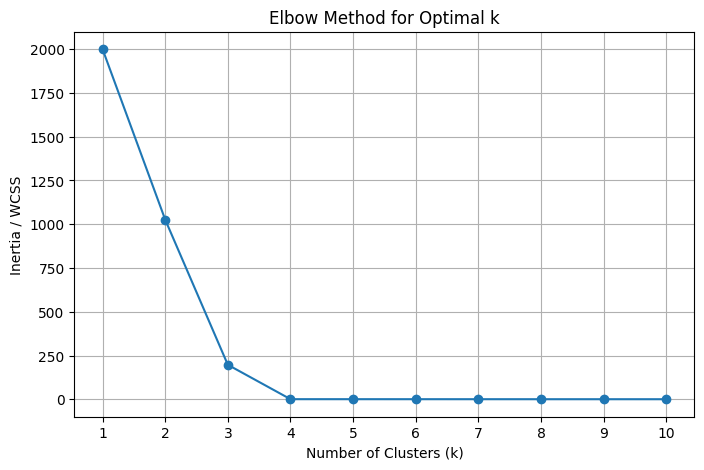

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(k_means, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_means)
plt.grid(True)

plt.show()

In [6]:
optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(x_scaled)

In [7]:
df["cluster"] = cluster_labels
df.head()

,feature_1,feature_2,cluster
0,-8.809999,7.297632,3
1,-6.805418,-6.850180,1
2,-6.823794,-6.872509,1
3,4.593943,1.888185,2
4,4.613920,1.822855,2


_Visualize final clusters_

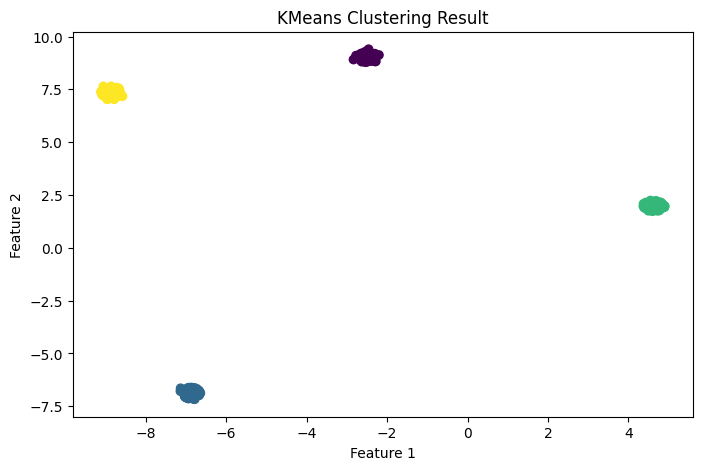

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["feature_1"],
    df["feature_2"],
    c=df["cluster"]
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering Result")
plt.show()